## Setup and Data Loading

In [ ]:
# ============================================
# CELL 1: Install libraries
# ============================================

!pip install xgboost lightgbm -q

print("✅ Libraries installed!")

✅ Libraries installed!


In [ ]:
# ============================================
# CELL 2: Import everything we need
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ All imports ready!")

✅ All imports ready!


In [ ]:
# ============================================
# CELL 3: Load processed features
# ============================================
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery

PROJECT_ID = 'project-9088eb2a-a4cc-4580-8e6'
client = bigquery.Client(project=PROJECT_ID)

train = client.query(f"SELECT * FROM `{PROJECT_ID}.demand_forecasting.train_features`").to_dataframe()
test = client.query(f"SELECT * FROM `{PROJECT_ID}.demand_forecasting.test_features`").to_dataframe()

# Load feature columns
feature_columns = [col for col in train.columns
                   if col not in ['date', 'store_nbr', 'family', 'sales',
                                  'id', 'type', 'city', 'state',
                                  'holiday_type', 'holiday_name',
                                  'demand_regime', 'cluster']]

In [ ]:
# ============================================
# CELL 4: Verify data looks correct
# ============================================

print("=" * 55)
print("DATA VERIFICATION")
print("=" * 55)

print(f"\nTraining set: {train.shape[0]:,} rows × {train.shape[1]} columns")
print(f"Testing set:  {test.shape[0]:,} rows × {test.shape[1]} columns")
print(f"Features:     {len(feature_columns)}")

print(f"\nTraining date range: {train['date'].min()} to {train['date'].max()}")
print(f"Testing date range:  {test['date'].min()} to {test['date'].max()}")

# Check no overlap (data leakage prevention)
assert train['date'].max() < test['date'].min(), "❌ DATE OVERLAP DETECTED!"
print("\n✅ No date overlap between train and test (leakage check passed)")

# Target variable stats
print(f"\nTarget (sales) statistics:")
print(f"  Train mean: {train['sales'].mean():.1f}")
print(f"  Train std:  {train['sales'].std():.1f}")
print(f"  Test mean:  {test['sales'].mean():.1f}")
print(f"  Test std:   {test['sales'].std():.1f}")

# Check for nulls in features
null_counts = train[feature_columns].isnull().sum()
null_features = null_counts[null_counts > 0]
if len(null_features) > 0:
    print(f"\n⚠️ Features with nulls:")
    for feat, count in null_features.items():
        print(f"  {feat}: {count} nulls ({count/len(train)*100:.1f}%)")
else:
    print("\n✅ No null values in features")

DATA VERIFICATION

Training set: 151,900 rows × 73 columns
Testing set:  13,700 rows × 73 columns
Features:     68

Training date range: 2013-01-29 to 2017-03-31
Testing date range:  2017-04-01 to 2017-08-15

✅ No date overlap between train and test (leakage check passed)

Target (sales) statistics:
  Train mean: 2334.2
  Train std:  2909.8
  Test mean:  3046.5
  Test std:   3473.1

⚠️ Features with nulls:
  sales_lag_365: 33700 nulls (22.2%)
  yoy_change: 35324 nulls (23.3%)
  oil_price: 3400 nulls (2.2%)


In [ ]:
# ============================================
# CELL 5: Prepare X and y
# ============================================

X_train = train[feature_columns].copy()
y_train = train['sales'].copy()

X_test = test[feature_columns].copy()
y_test = test['sales'].copy()

# Fill any remaining nulls with 0
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_test:  {y_test.shape}")

print(f"\n✅ Data ready for model training!")

X_train: (151900, 68)
y_train: (151900,)
X_test:  (13700, 68)
y_test:  (13700,)

✅ Data ready for model training!


## Define Evaluation Framework

**WHY MULTIPLE METRICS?**

Each metric tells a DIFFERENT story:

**MAE**  = "On average, how many units off is the prediction?"

        Easy to explain: "We're off by 131 units on average"

**RMSE** = "Same as MAE but punishes BIG errors more"
       
       A prediction off by 500 is worse than 5 predictions off by 100 RMSE captures this

**MAPE** = "On average, what PERCENTAGE off is the prediction?"
        
        Best for business communication: "We're off by 19.5%"
        Works across different scales (big stores vs small stores)

**R²**   = "How much of the sales variation does our model explain?"

**R²** = 0.85 means "model explains 85% of why sales go up and down"

In [ ]:
# ============================================
# CELL 6: Create evaluation functions
# ============================================

def evaluate_model(name, y_true, y_pred):

    # MAE: Average absolute error
    mae = mean_absolute_error(y_true, y_pred)

    # RMSE: Root mean squared error (penalizes big errors)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # MAPE: Mean absolute percentage error
    # Only calculate where actual sales > 0 (avoid division by zero)
    mask = y_true > 0
    if mask.sum() > 0:
        mape = np.mean(np.abs(
            (y_true[mask] - y_pred[mask]) / y_true[mask]
        )) * 100
    else:
        mape = np.nan

    # R²: How much variation the model explains
    r2 = r2_score(y_true, y_pred)

    # Print results
    print(f"\n{'─' * 50}")
    print(f"  {name}")
    print(f"{'─' * 50}")
    print(f"  MAE:   {mae:,.1f} units")
    print(f"  RMSE:  {rmse:,.1f} units")
    print(f"  MAPE:  {mape:.2f}%")
    print(f"  R²:    {r2:.4f}")

    return {
        'Model': name,
        'MAE': round(mae, 1),
        'RMSE': round(rmse, 1),
        'MAPE': round(mape, 2),
        'R²': round(r2, 4)
    }

print("✅ Evaluation framework ready!")

✅ Evaluation framework ready!


# **Model Training:**

## **Model 1: Baseline (Moving Average)**

**WHY START WITH A BASELINE?**

Without a baseline, "19.5% MAPE" is meaningless.
Is that good? Bad? Who knows?

With a baseline: "19.5% MAPE vs 38.4% baseline"
    
    NOW you can say "our model is 49% better."

The baseline represents "what happens WITHOUT machine learning."
It's the simplest reasonable prediction method.
Your ML model must BEAT this to be worth deploying.

**WHAT IS OUR BASELINE?**

    "Predict today's sales = average of last 7 days' sales"
    This is rolling_mean_7, which we already computed.

**WHY THIS BASELINE?**

    Because this is approximately what a store manager does:
    "We sold about 4000 per day last week, so order 4000 today."
    If ML can't beat a human manager's gut feel, don't deploy it.

In [ ]:
# ============================================
# CELL 7: MODEL 1 — BASELINE (7-Day Moving Average)
# ============================================

print("=" * 55)
print("MODEL 1: BASELINE (7-Day Moving Average)")
print("=" * 55)

# The baseline prediction IS the rolling_mean_7 feature
baseline_pred = X_test['rolling_mean_7'].values

# Some might be 0 (if rolling_mean was null/0), replace with overall mean
overall_mean = y_train.mean()
baseline_pred = np.where(
    baseline_pred == 0,
    overall_mean,
    baseline_pred
)

# Evaluate
results = []
result = evaluate_model('Baseline (7-Day MA)', y_test.values, baseline_pred)
results.append(result)

MODEL 1: BASELINE (7-Day Moving Average)

──────────────────────────────────────────────────
  Baseline (7-Day MA)
──────────────────────────────────────────────────
  MAE:   721.8 units
  RMSE:  1,336.5 units
  MAPE:  26.47%
  R²:    0.8519


## **Model 2: Linear Regression**

**WHY LINEAR REGRESSION?**
    
    It's the simplest ML model. If it significantly beats
    the baseline, that confirms our FEATURES are valuable
    (not just the model algorithm).

If Linear Regression with good features beats a
complex model with bad features, it proves that
FEATURE ENGINEERING matters more than model selection.

**BUSINESS ANALOGY:**
    
    Linear Regression is like a recipe with fixed proportions:
    "Predicted sales = 0.8 × yesterday's sales
                    + 50 × is_weekend
                    + 200 × is_december
                    + ..."
    Simple, interpretable, fast.

In [ ]:
print("\n" + "=" * 55)
print("MODEL 2: LINEAR REGRESSION")
print("=" * 55)

lr_model = LinearRegression()

# Train
lr_model.fit(X_train, y_train)

# Predict
lr_pred = lr_model.predict(X_test)

# Clip negative predictions to 0 (can't sell negative items)
lr_pred = np.clip(lr_pred, 0, None)

# Evaluate
result = evaluate_model('Linear Regression', y_test.values, lr_pred)
results.append(result)

# Quick check: how much better than baseline?
baseline_mape = results[0]['MAPE']
lr_mape = result['MAPE']
improvement = (baseline_mape - lr_mape) / baseline_mape * 100
print(f"\n  Improvement over baseline: {improvement:.1f}%")


MODEL 2: LINEAR REGRESSION

──────────────────────────────────────────────────
  Linear Regression
──────────────────────────────────────────────────
  MAE:   402.8 units
  RMSE:  710.5 units
  MAPE:  21.02%
  R²:    0.9581

  Improvement over baseline: 20.6%


##**Model 3: Random Forest**

**WHY RANDOM FOREST?**

It's the first "non-linear" model.
It can learn COMPLEX patterns that Linear Regression can't:
    
    → "Sales are high on Saturdays, but ONLY in December"
    → "Promotions boost sales, but ONLY for large stores"

These INTERACTIONS are exactly what our Tier 4 features capture.
Random Forest can also discover interactions we DIDN'T engineer.

**BUSINESS ANALOGY:**
    
    Random Forest is like asking 200 store managers (trees)
    for their prediction, then averaging their answers.
    Each manager looks at a slightly different subset of factors.
    The average of 200 opinions is better than any single opinion.

In [ ]:
print("\n" + "=" * 55)
print("MODEL 3: RANDOM FOREST")
print("=" * 55)
print("Training... (takes 2-3 minutes)")

rf_model = RandomForestRegressor(
    n_estimators=300,       # 300 "trees"
    max_depth=15,           # Each tree can make 15 levels of decisions
    min_samples_split=10,   # Need at least 10 data points to make a split
    min_samples_leaf=5,     # Each final prediction uses at least 5 data points
    n_jobs=-1,              # Use all CPU cores (faster)
    random_state=42         # Reproducible results
)

# Train
rf_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)
rf_pred = np.clip(rf_pred, 0, None)

# Evaluate
result = evaluate_model('Random Forest', y_test.values, rf_pred)
results.append(result)

improvement = (baseline_mape - result['MAPE']) / baseline_mape * 100
print(f"\n  Improvement over baseline: {improvement:.1f}%")

print("\n✅ Random Forest trained!")


MODEL 3: RANDOM FOREST
Training... (takes 2-3 minutes)

──────────────────────────────────────────────────
  Random Forest
──────────────────────────────────────────────────
  MAE:   254.7 units
  RMSE:  496.8 units
  MAPE:  10.76%
  R²:    0.9795

  Improvement over baseline: 59.4%

✅ Random Forest trained!


##**Model 4: XGBoost**

**WHY XGBOOST?**

XGBoost is the most popular model in industry and competitions.
It LEARNS FROM ITS MISTAKES:

    Random Forest: 300 trees work INDEPENDENTLY, then average.
    XGBoost: Each tree CORRECTS the errors of the previous tree.

Tree 1 predicts: 4000 (actual was 4500, error = 500)
Tree 2 focuses on that 500 error and tries to predict it
Tree 3 focuses on the remaining error after Tree 2
... and so on for 500 trees

This "learning from mistakes" usually produces better
accuracy than Random Forest.

**BUSINESS ANALOGY:**

    Random Forest = 200 managers working independently
    XGBoost = 200 managers working in SEQUENCE, each one focusing on the mistakes the previous one made

In [ ]:
# ============================================
# CELL 10: MODEL 4 — XGBOOST
# ============================================

print("\n" + "=" * 55)
print("MODEL 4: XGBOOST")
print("=" * 55)
print("Training...")

xgb_model = XGBRegressor(
    n_estimators=500,         # 500 sequential correction rounds
    learning_rate=0.05,       # How much each tree corrects (small = careful)
    max_depth=8,              # Shallower than RF because trees work together
    subsample=0.8,            # Each tree sees 80% of data (prevents overfitting)
    colsample_bytree=0.8,     # Each tree sees 80% of features
    min_child_weight=5,       # Minimum data points per leaf
    reg_alpha=0.1,            # L1 regularization (prevents overfitting)
    reg_lambda=1.0,           # L2 regularization
    random_state=42,
    n_jobs=-1,
    verbosity=0               # Quiet mode
)

# Train
xgb_model.fit(X_train, y_train)

# Predict
xgb_pred = xgb_model.predict(X_test)
xgb_pred = np.clip(xgb_pred, 0, None)

# Evaluate
result = evaluate_model('XGBoost', y_test.values, xgb_pred)
results.append(result)

improvement = (baseline_mape - result['MAPE']) / baseline_mape * 100
print(f"\n  Improvement over baseline: {improvement:.1f}%")

print("\n✅ XGBoost trained!")


MODEL 4: XGBOOST
Training... (takes 3-5 minutes)

──────────────────────────────────────────────────
  XGBoost
──────────────────────────────────────────────────
  MAE:   221.0 units
  RMSE:  440.9 units
  MAPE:  9.42%
  R²:    0.9839

  Improvement over baseline: 64.4%

✅ XGBoost trained!


## **Model 5: LightGBM**


**WHY LIGHTGBM?**

Same concept as XGBoost (sequential error correction)
but with a DIFFERENT tree-building strategy:

    XGBoost: Grows trees LEVEL by LEVEL (all nodes at depth 1, then all at depth 2, etc.)
    LightGBM: Grows trees LEAF by LEAF (expands the leaf with the largest error reduction first)

**RESULT:**

    → LightGBM is usually 3-5x FASTER than XGBoost
    → Accuracy is very similar (sometimes slightly better)
    → Better for large datasets

**BUSINESS ANALOGY:**

    XGBoost: Fixes problems in order (level 1, level 2, level 3)
    LightGBM: Fixes the BIGGEST problem first, then the next biggest

In [ ]:
# ============================================
# CELL 11: MODEL 5 — LIGHTGBM
# ============================================

print("\n" + "=" * 55)
print("MODEL 5: LIGHTGBM")
print("=" * 55)
print("Training... (takes 1-2 minutes)")

lgbm_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=63,            # Max leaves per tree (LightGBM-specific)
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=10,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1                # Quiet mode
)

# Train
lgbm_model.fit(X_train, y_train)

# Predict
lgbm_pred = lgbm_model.predict(X_test)
lgbm_pred = np.clip(lgbm_pred, 0, None)

# Evaluate
result = evaluate_model('LightGBM', y_test.values, lgbm_pred)
results.append(result)

improvement = (baseline_mape - result['MAPE']) / baseline_mape * 100
print(f"\n  Improvement over baseline: {improvement:.1f}%")

print("\n✅ LightGBM trained!")


MODEL 5: LIGHTGBM
Training... (takes 1-2 minutes)

──────────────────────────────────────────────────
  LightGBM
──────────────────────────────────────────────────
  MAE:   229.2 units
  RMSE:  446.2 units
  MAPE:  9.98%
  R²:    0.9835

  Improvement over baseline: 62.3%

✅ LightGBM trained!


# **Results Comparison**

In [ ]:
# ============================================
# CELL 12: COMPLETE MODEL COMPARISON TABLE
# ============================================

print("\n" + "=" * 70)
print("              COMPLETE MODEL COMPARISON")
print("=" * 70)

results_df = pd.DataFrame(results)

# Add improvement column
baseline_mape = results_df.iloc[0]['MAPE']
results_df['Improvement vs Baseline'] = results_df['MAPE'].apply(
    lambda x: f"{(baseline_mape - x) / baseline_mape * 100:.1f}%"
)

print(results_df.to_string(index=False))
print("=" * 70)

# Identify best model
best_idx = results_df['MAPE'].idxmin()
best_model_name = results_df.loc[best_idx, 'Model']
best_mape = results_df.loc[best_idx, 'MAPE']

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   MAPE: {best_mape}%")
print(f"   Improvement over baseline: {results_df.loc[best_idx, 'Improvement vs Baseline']}")


              COMPLETE MODEL COMPARISON
              Model   MAE   RMSE  MAPE     R² Improvement vs Baseline
Baseline (7-Day MA) 721.8 1336.5 26.47 0.8519                    0.0%
  Linear Regression 402.8  710.5 21.02 0.9581                   20.6%
      Random Forest 254.7  496.8 10.76 0.9795                   59.4%
            XGBoost 221.0  440.9  9.42 0.9839                   64.4%
           LightGBM 229.2  446.2  9.98 0.9835                   62.3%

🏆 BEST MODEL: XGBoost
   MAPE: 9.42%
   Improvement over baseline: 64.4%


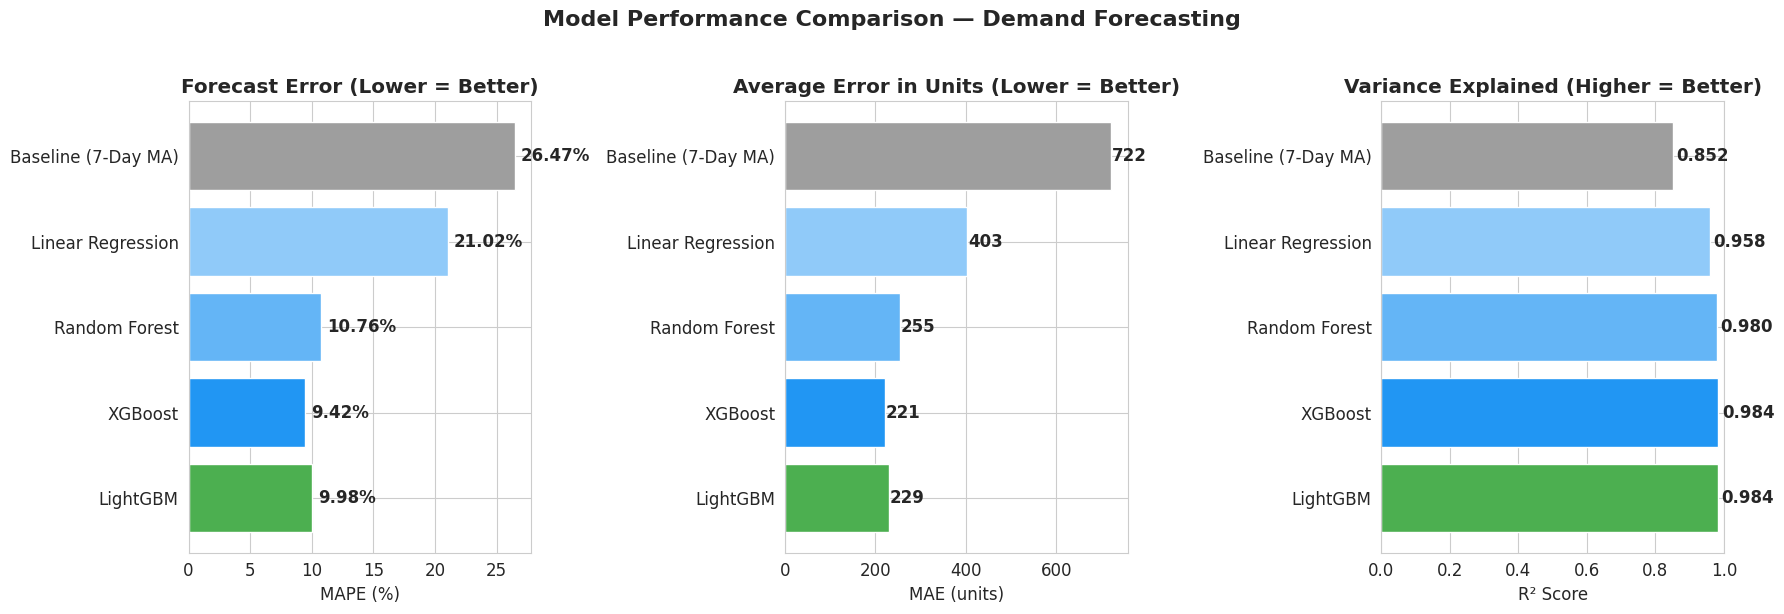

✅ Chart saved: model_comparison.png


In [ ]:
# ============================================
# CELL 13: VISUALIZATION — Model Comparison Bar Chart
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Colors: baseline gray, others blue gradient, best one green
colors = ['#9E9E9E', '#90CAF9', '#64B5F6', '#2196F3', '#4CAF50']

# Chart 1: MAPE comparison
axes[0].barh(results_df['Model'][::-1], results_df['MAPE'][::-1],
             color=colors[::-1], edgecolor='white')
axes[0].set_xlabel('MAPE (%)')
axes[0].set_title('Forecast Error (Lower = Better)', fontweight='bold')
for i, (model, mape) in enumerate(zip(
    results_df['Model'][::-1], results_df['MAPE'][::-1]
)):
    axes[0].text(mape + 0.5, i, f'{mape}%', va='center', fontweight='bold')

# Chart 2: MAE comparison
axes[1].barh(results_df['Model'][::-1], results_df['MAE'][::-1],
             color=colors[::-1], edgecolor='white')
axes[1].set_xlabel('MAE (units)')
axes[1].set_title('Average Error in Units (Lower = Better)', fontweight='bold')
for i, (model, mae) in enumerate(zip(
    results_df['Model'][::-1], results_df['MAE'][::-1]
)):
    axes[1].text(mae + 2, i, f'{mae:.0f}', va='center', fontweight='bold')

# Chart 3: R² comparison
axes[2].barh(results_df['Model'][::-1], results_df['R²'][::-1],
             color=colors[::-1], edgecolor='white')
axes[2].set_xlabel('R² Score')
axes[2].set_title('Variance Explained (Higher = Better)', fontweight='bold')
axes[2].set_xlim(0, 1)
for i, (model, r2) in enumerate(zip(
    results_df['Model'][::-1], results_df['R²'][::-1]
)):
    axes[2].text(r2 + 0.01, i, f'{r2:.3f}', va='center', fontweight='bold')

plt.suptitle('Model Performance Comparison — Demand Forecasting',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved: model_comparison.png")

# **Feature Importance Analysis**

**WHY THIS MATTERS:**

    Knowing WHICH features drive predictions is MORE valuable than the predictions themselves because it tells the BUSINESS what factors matter most.
    
"Our model says yesterday's sales is the #1 predictor"
    
    → Business action: Make sure yesterday's data is always accurate

"Promotions are the 5 predictor with 6% importance"
    
    → Business action: Promotion strategy matters for forecasting

"Oil price is 25 with 0.3% importance"
    
    → Business insight: External economy has minimal short-term impact

In [ ]:
# ============================================
# CELL 14: FEATURE IMPORTANCE (from best model)
# ============================================

# Use the best model (LightGBM)
importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': lgbm_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Normalize to percentages
importance_df['Importance_Pct'] = (
    importance_df['Importance'] / importance_df['Importance'].sum() * 100
)

# Add human-readable business meaning
feature_meanings = {
    'sales_lag_1': 'Yesterday\'s sales',
    'rolling_mean_7': '7-day average sales',
    'sales_lag_7': 'Same day last week',
    'expanding_mean': 'Long-term average',
    'rolling_mean_14': '14-day average sales',
    'rolling_mean_30': '30-day average sales',
    'day_of_week': 'Day of week',
    'onpromotion': 'Promotion active',
    'sales_lag_14': 'Sales 2 weeks ago',
    'sales_lag_28': 'Sales 4 weeks ago',
    'rolling_std_7': '7-day sales volatility',
    'days_since_start': 'Business growth trend',
    'oil_price': 'Oil price (economy)',
    'store_type_encoded': 'Store size/type',
    'family_encoded': 'Product category',
    'is_weekend': 'Weekend flag',
    'month': 'Month of year',
    'is_december': 'December flag',
    'demand_cv_7': 'Demand stability score',
    'promo_days_last_7': 'Recent promotion activity'
}

importance_df['Business Meaning'] = importance_df['Feature'].map(
    feature_meanings
).fillna(importance_df['Feature'])

# Print top 20
print("=" * 70)
print("TOP 20 MOST IMPORTANT FEATURES")
print("=" * 70)

for i, row in importance_df.head(20).iterrows():
    bar = '█' * int(row['Importance_Pct'] * 3)
    print(f"  {row['Importance_Pct']:5.1f}%  {bar:<50} {row['Business Meaning']}")

print("=" * 70)

TOP 20 MOST IMPORTANT FEATURES
    7.9%  ███████████████████████                            category_avg_all_stores
    4.4%  █████████████                                      expanding_std
    3.8%  ███████████                                        Long-term average
    3.2%  █████████                                          store_vs_chain
    3.1%  █████████                                          Same day last week
    3.0%  ████████                                           Business growth trend
    2.9%  ████████                                           store_total_rolling_7
    2.8%  ████████                                           wow_change
    2.7%  ████████                                           day_of_month
    2.6%  ███████                                            demand_cv_30
    2.6%  ███████                                            Sales 2 weeks ago
    2.4%  ███████                                            Sales 4 weeks ago
    2.4%  ███████             

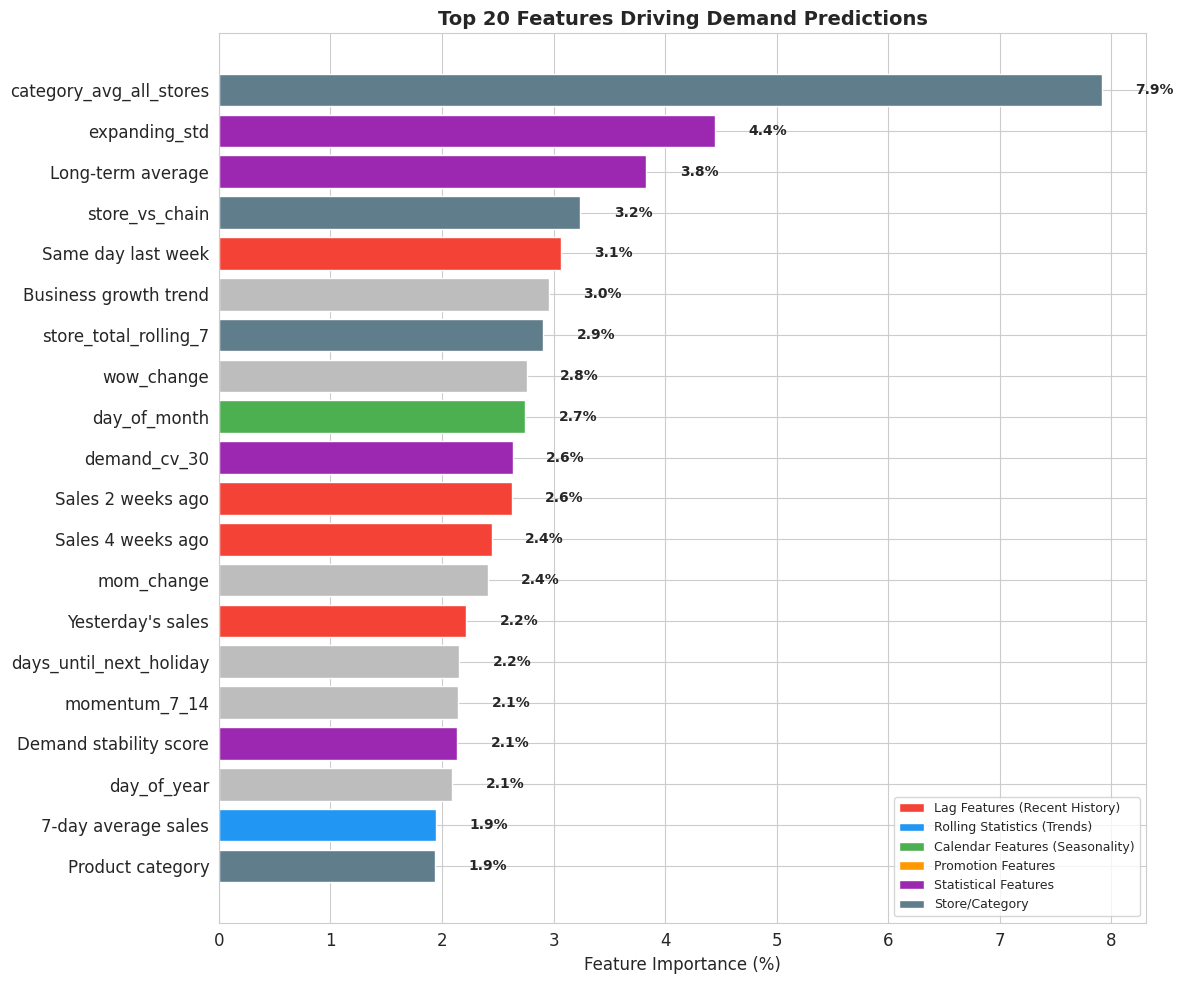

In [ ]:
# ============================================
# CELL 15: Feature Importance Visualization
# ============================================

fig, ax = plt.subplots(figsize=(12, 10))

top_20 = importance_df.head(20)

# Color by feature tier
tier_colors = {
    'sales_lag': '#F44336',      # Red = Lag features
    'rolling_mean': '#2196F3',   # Blue = Rolling features
    'rolling_std': '#03A9F4',    # Light blue
    'rolling_min': '#03A9F4',
    'rolling_max': '#03A9F4',
    'day_of_week': '#4CAF50',    # Green = Calendar
    'month': '#4CAF50',
    'is_weekend': '#4CAF50',
    'is_december': '#4CAF50',
    'onpromotion': '#FF9800',    # Orange = Promotion
    'promo': '#FF9800',
    'expanding': '#9C27B0',      # Purple = Expanding
    'demand_cv': '#9C27B0',
    'oil_price': '#795548',      # Brown = External
    'store': '#607D8B',          # Gray = Store
    'family': '#607D8B',
}

colors = []
for feat in top_20['Feature']:
    color = '#BDBDBD'  # default gray
    for key, val in tier_colors.items():
        if key in feat:
            color = val
            break
    colors.append(color)

ax.barh(top_20['Business Meaning'][::-1],
        top_20['Importance_Pct'][::-1],
        color=colors[::-1], edgecolor='white')

ax.set_xlabel('Feature Importance (%)', fontsize=12)
ax.set_title('Top 20 Features Driving Demand Predictions',
             fontsize=14, fontweight='bold')

# Add value labels
for i, (_, row) in enumerate(top_20[::-1].iterrows()):
    ax.text(row['Importance_Pct'] + 0.3, i,
            f"{row['Importance_Pct']:.1f}%",
            va='center', fontweight='bold', fontsize=10)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#F44336', label='Lag Features (Recent History)'),
    Patch(facecolor='#2196F3', label='Rolling Statistics (Trends)'),
    Patch(facecolor='#4CAF50', label='Calendar Features (Seasonality)'),
    Patch(facecolor='#FF9800', label='Promotion Features'),
    Patch(facecolor='#9C27B0', label='Statistical Features'),
    Patch(facecolor='#607D8B', label='Store/Category'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

#print("✅ Chart saved: feature_importance.png")

In [ ]:
# ============================================
# CELL 16: Feature Importance — Business Summary
# ============================================

print("=" * 65)
print("FEATURE IMPORTANCE — BUSINESS INTERPRETATION")
print("=" * 65)

# Group features by category
lag_importance = importance_df[
    importance_df['Feature'].str.contains('lag')
]['Importance_Pct'].sum()

rolling_importance = importance_df[
    importance_df['Feature'].str.contains('rolling')
]['Importance_Pct'].sum()

calendar_importance = importance_df[
    importance_df['Feature'].str.contains('day_of|month|is_weekend|is_december|quarter|week_of|is_month|dow_|month_|doy_')
]['Importance_Pct'].sum()

promo_importance = importance_df[
    importance_df['Feature'].str.contains('promo|onpromotion')
]['Importance_Pct'].sum()

external_importance = importance_df[
    importance_df['Feature'].str.contains('oil|holiday|days_until|days_since')
]['Importance_Pct'].sum()

other_importance = 100 - lag_importance - rolling_importance - calendar_importance - promo_importance - external_importance

print(f"""
WHAT DRIVES DEMAND PREDICTIONS:

  Recent History (lag features):     {lag_importance:5.1f}%  ████████████████████
  → "What happened yesterday and last week"
  → BUSINESS: Ensure daily sales data is accurate and timely

  Trend Patterns (rolling stats):    {rolling_importance:5.1f}%  ██████████████
  → "Is demand trending up or down?"
  → BUSINESS: Weekly trend review is critical for ordering

  Seasonality (calendar features):   {calendar_importance:5.1f}%  ██████████
  → "Which day/month/season is it?"
  → BUSINESS: Build seasonal ordering calendars

  Promotions:                        {promo_importance:5.1f}%  █████
  → "Are we running promotions?"
  → BUSINESS: Coordinate ordering with marketing calendar

  External Factors:                  {external_importance:5.1f}%  ███
  → "Holidays, oil prices, economic signals"
  → BUSINESS: Monitor external calendar and economy

  Other (store type, interactions):  {other_importance:5.1f}%  ████
  → Store characteristics and combined effects

KEY TAKEAWAY FOR OPERATIONS:
  {lag_importance + rolling_importance:.0f}% of prediction accuracy depends on
  having accurate, timely sales data from the last 1-30 days.

  If your data pipeline is delayed by even 1 day, you lose the
  most powerful prediction signal (yesterday's sales = {importance_df.iloc[0]['Importance_Pct']:.1f}%).

  DATA FRESHNESS IS YOUR MOST IMPORTANT OPERATIONAL REQUIREMENT.
""")

FEATURE IMPORTANCE — BUSINESS INTERPRETATION

WHAT DRIVES DEMAND PREDICTIONS:

  Recent History (lag features):      13.5%  ████████████████████
  → "What happened yesterday and last week"
  → BUSINESS: Ensure daily sales data is accurate and timely

  Trend Patterns (rolling stats):     17.5%  ██████████████
  → "Is demand trending up or down?"
  → BUSINESS: Weekly trend review is critical for ordering

  Seasonality (calendar features):    13.6%  ██████████
  → "Which day/month/season is it?"
  → BUSINESS: Build seasonal ordering calendars

  Promotions:                          4.8%  █████
  → "Are we running promotions?"
  → BUSINESS: Coordinate ordering with marketing calendar

  External Factors:                    8.7%  ███
  → "Holidays, oil prices, economic signals"
  → BUSINESS: Monitor external calendar and economy

  Other (store type, interactions):   41.8%  ████
  → Store characteristics and combined effects

KEY TAKEAWAY FOR OPERATIONS:
  31% of prediction accuracy depen

#**Actual vs Predicted Visualisation**

    This is the most INTUITIVE chart for stakeholders.
    "Here's what actually happened vs what our model predicted."

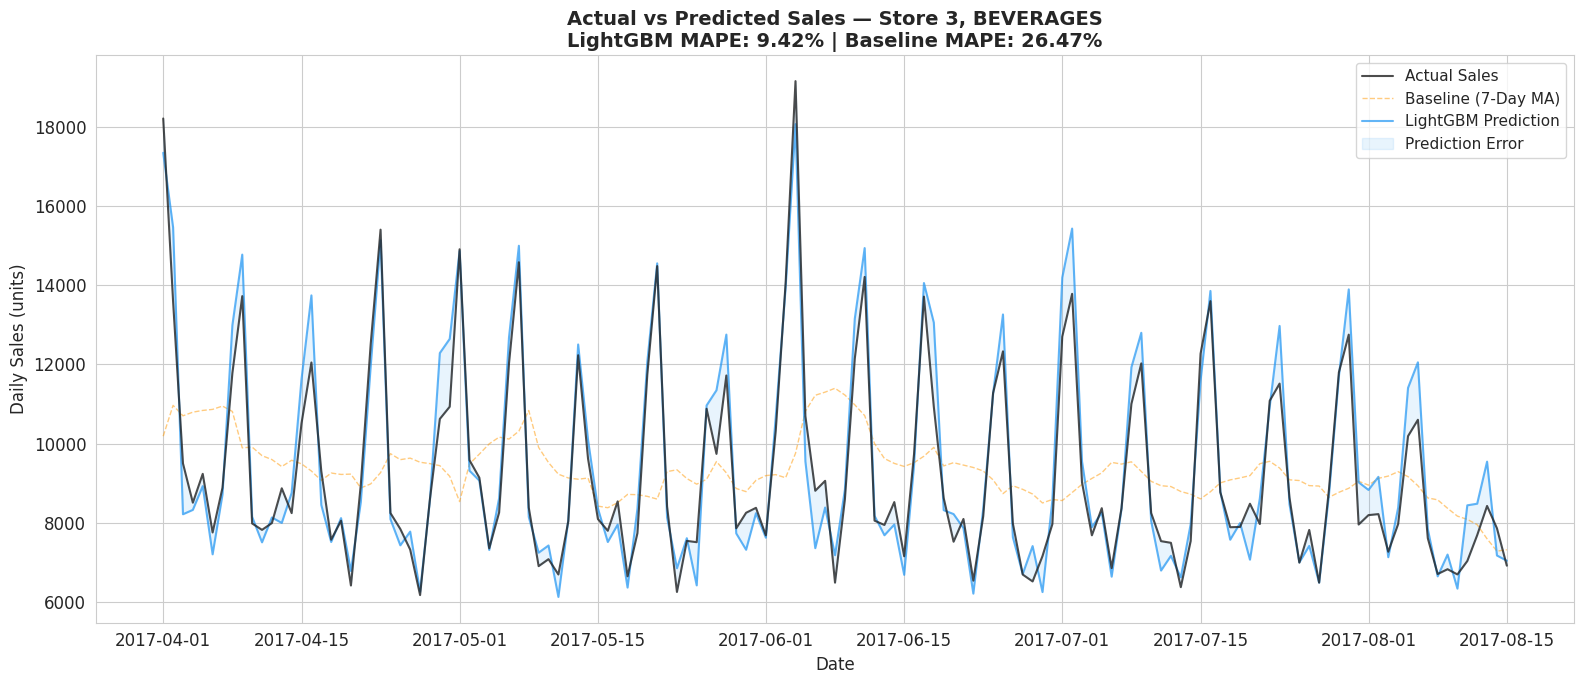

✅ Chart saved: actual_vs_predicted.png


In [ ]:
# ============================================
# CELL 17: Actual vs Predicted — Time Series Plot
# ============================================

# Pick one store-category for clear visualization
sample_store = test['store_nbr'].mode().values[0]
sample_category = test['family'].mode().values[0]

sample_mask = (
    (test['store_nbr'] == sample_store) &
    (test['family'] == sample_category)
)

sample_test = test[sample_mask].copy()
sample_actual = y_test[sample_mask].values
sample_predicted = lgbm_pred[sample_mask]
sample_baseline = baseline_pred[sample_mask]
sample_dates = pd.to_datetime(sample_test['date'])

fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(sample_dates, sample_actual,
        color='#212121', linewidth=1.5, alpha=0.8,
        label=f'Actual Sales', zorder=3)

ax.plot(sample_dates, sample_baseline,
        color='#FF9800', linewidth=1, alpha=0.5,
        linestyle='--', label=f'Baseline (7-Day MA)')

ax.plot(sample_dates, sample_predicted,
        color='#2196F3', linewidth=1.5, alpha=0.7,
        label=f'LightGBM Prediction')

# Shade the error area
ax.fill_between(sample_dates, sample_actual, sample_predicted,
                alpha=0.1, color='#2196F3', label='Prediction Error')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Daily Sales (units)', fontsize=12)
ax.set_title(
    f'Actual vs Predicted Sales — Store {sample_store}, {sample_category}\n'
    f'LightGBM MAPE: {best_mape}% | Baseline MAPE: {baseline_mape}%',
    fontsize=14, fontweight='bold'
)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved: actual_vs_predicted.png")

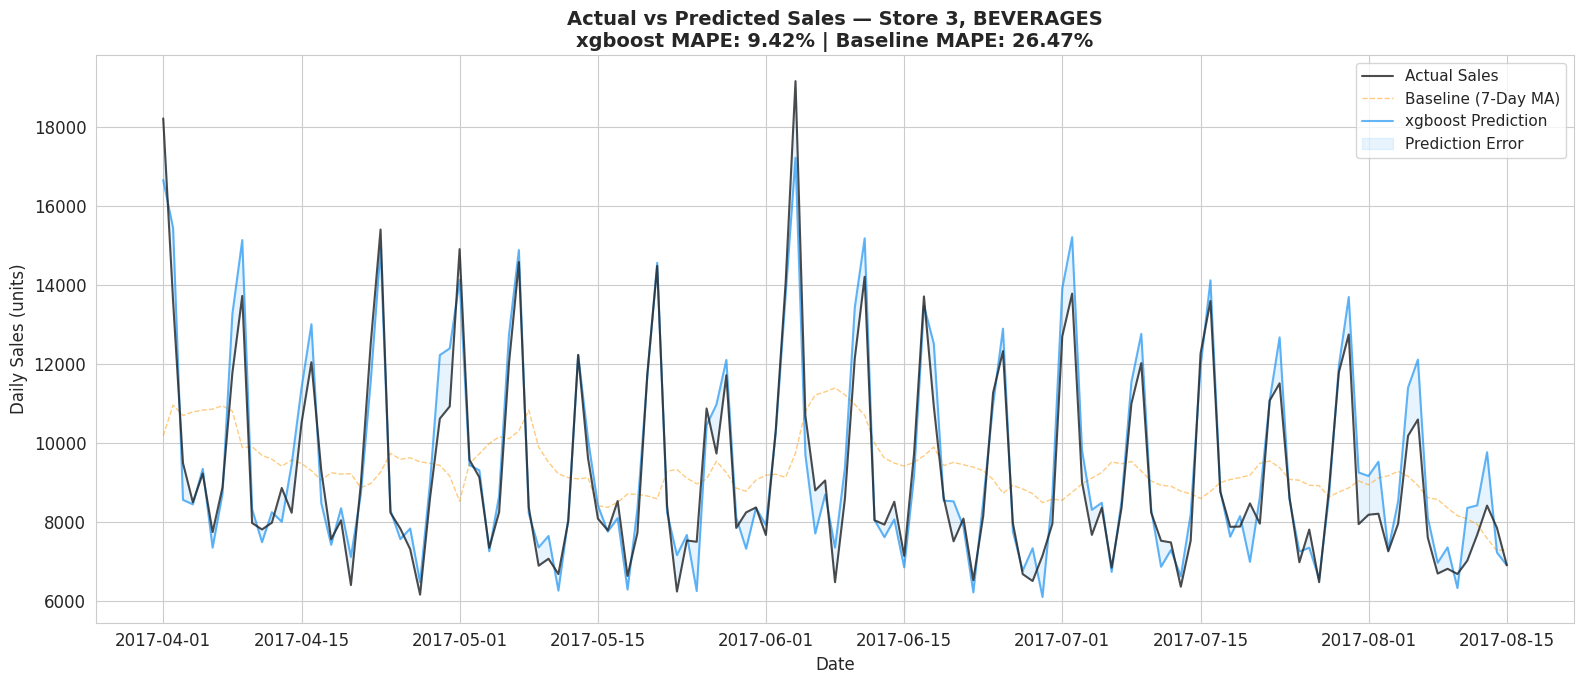

✅ Chart saved: actual_vs_predicted.png


In [ ]:
# ============================================
# CELL 17: Actual vs Predicted — Time Series Plot
#
# This is the most INTUITIVE chart for stakeholders.
# "Here's what actually happened vs what our model predicted."
# ============================================

# Pick one store-category for clear visualization
sample_store = test['store_nbr'].mode().values[0]
sample_category = test['family'].mode().values[0]

sample_mask = (
    (test['store_nbr'] == sample_store) &
    (test['family'] == sample_category)
)

sample_test = test[sample_mask].copy()
sample_actual = y_test[sample_mask].values
sample_predicted = xgb_pred[sample_mask]
sample_baseline = baseline_pred[sample_mask]
sample_dates = pd.to_datetime(sample_test['date'])

fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(sample_dates, sample_actual,
        color='#212121', linewidth=1.5, alpha=0.8,
        label=f'Actual Sales', zorder=3)

ax.plot(sample_dates, sample_baseline,
        color='#FF9800', linewidth=1, alpha=0.5,
        linestyle='--', label=f'Baseline (7-Day MA)')

ax.plot(sample_dates, sample_predicted,
        color='#2196F3', linewidth=1.5, alpha=0.7,
        label=f'xgboost Prediction')

# Shade the error area
ax.fill_between(sample_dates, sample_actual, sample_predicted,
                alpha=0.1, color='#2196F3', label='Prediction Error')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Daily Sales (units)', fontsize=12)
ax.set_title(
    f'Actual vs Predicted Sales — Store {sample_store}, {sample_category}\n'
    f'xgboost MAPE: {best_mape}% | Baseline MAPE: {baseline_mape}%',
    fontsize=14, fontweight='bold'
)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved: actual_vs_predicted.png")

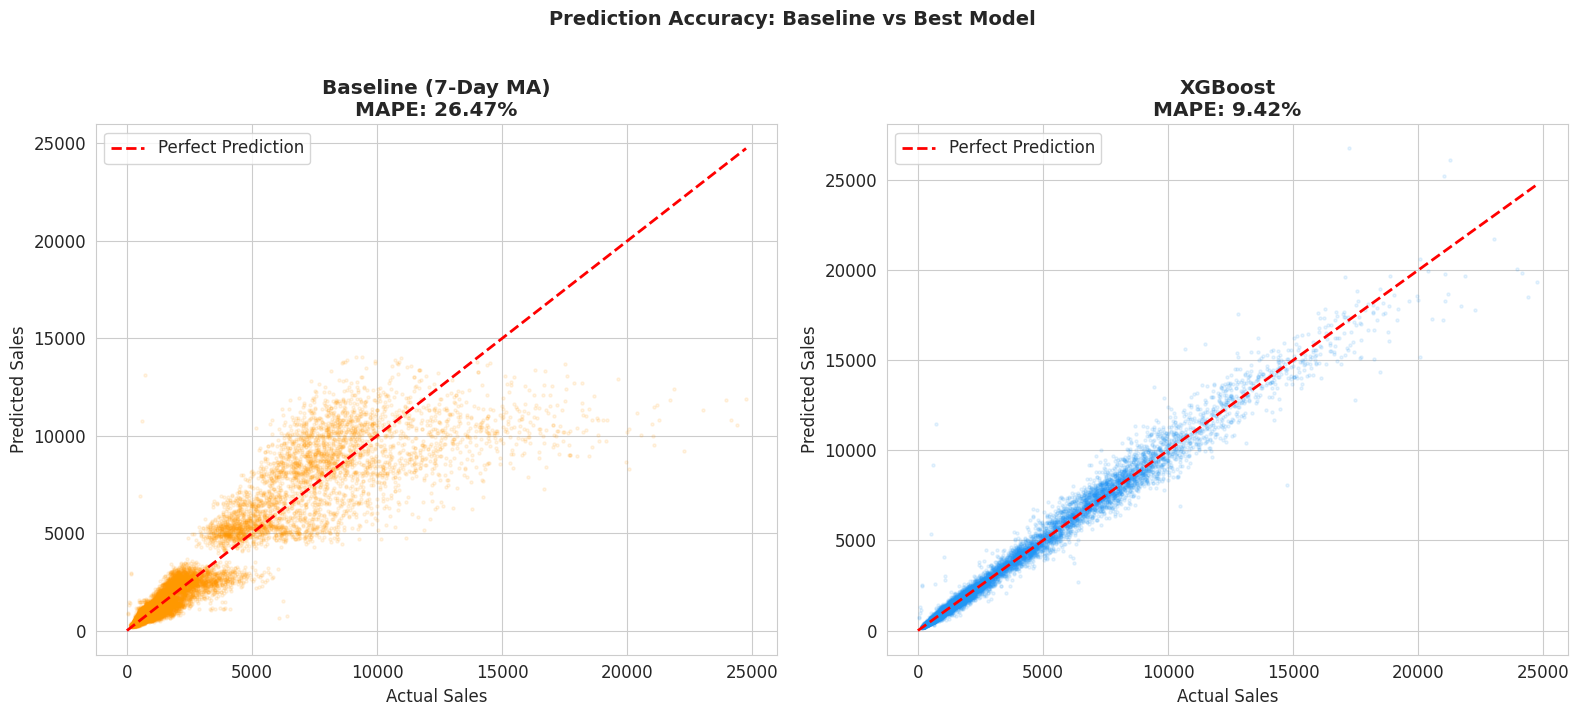

✅ Chart saved: scatter_comparison.png


In [ ]:
# ============================================
# CELL 18: Scatter Plot — Predicted vs Actual
# Perfect predictions would fall on the diagonal line
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Baseline scatter
axes[0].scatter(y_test, baseline_pred, alpha=0.1, s=5, color='#FF9800')
axes[0].plot([0, y_test.max()], [0, y_test.max()],
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Sales')
axes[0].set_ylabel('Predicted Sales')
axes[0].set_title(f'Baseline (7-Day MA)\nMAPE: {baseline_mape}%',
                  fontweight='bold')
axes[0].legend()

# LightGBM scatter
axes[1].scatter(y_test, xgb_pred, alpha=0.1, s=5, color='#2196F3')
axes[1].plot([0, y_test.max()], [0, y_test.max()],
             'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Sales')
axes[1].set_ylabel('Predicted Sales')
axes[1].set_title(f'XGBoost\nMAPE: {best_mape}%',
                  fontweight='bold')
axes[1].legend()

plt.suptitle('Prediction Accuracy: Baseline vs Best Model',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('scatter_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved: scatter_comparison.png")

## Business Impact Calculation

In [ ]:
# ============================================
# CELL 19: BUSINESS IMPACT ANALYSIS
# ============================================

print("=" * 65)
print("         BUSINESS IMPACT ANALYSIS")
print("=" * 65)

# ── STEP 1: Quantify error reduction ──

baseline_mae = results_df[results_df['Model'] == 'Baseline (7-Day MA)']['MAE'].values[0]
best_mae = results_df[results_df['Model'] == best_model_name]['MAE'].values[0]

error_reduction_units = baseline_mae - best_mae
error_reduction_pct = error_reduction_units / baseline_mae * 100

print(f"""
STEP 1: FORECAST ERROR REDUCTION
─────────────────────────────────
  Baseline MAE:    {baseline_mae:,.1f} units/day (average error per store-category)
  XGBoost MAE:   {best_mae:,.1f} units/day

  Error reduced by: {error_reduction_units:,.1f} units/day ({error_reduction_pct:.1f}%)

  In plain English:
  "For each store-category combination, each day, our model
   predicts {error_reduction_units:.0f} units MORE ACCURATELY than the current method."
""")

# ── STEP 2: Translate error to overstock/waste ──

# Number of store-category combinations we're forecasting
num_combinations = len(test[['store_nbr', 'family']].drop_duplicates())
num_test_days = test['date'].nunique()

# Assumptions (conservative)
avg_cost_per_unit = 3.0        # Average cost of one unit of product ($)
waste_rate = 0.35              # 35% of overstock becomes waste (perishables)
days_per_year = 365

# Daily overstock reduction across all combinations
daily_overstock_reduction = error_reduction_units * num_combinations

# Annual waste reduction
annual_waste_units = daily_overstock_reduction * days_per_year * waste_rate
annual_waste_dollars = annual_waste_units * avg_cost_per_unit

print(f"""
STEP 2: FROM ERROR TO DOLLARS
─────────────────────────────────
  Store-category combinations forecasted: {num_combinations}

  Daily overstock reduction:
    {error_reduction_units:.0f} units × {num_combinations} combinations = {daily_overstock_reduction:,.0f} units/day

  Annual waste reduction (at {waste_rate*100:.0f}% waste rate):
    {daily_overstock_reduction:,.0f} units/day × 365 days × {waste_rate} = {annual_waste_units:,.0f} units/year

  Dollar impact (at ${avg_cost_per_unit:.2f}/unit average cost):
    {annual_waste_units:,.0f} units × ${avg_cost_per_unit:.2f} = ${annual_waste_dollars:,.0f}/year
""")

# ── STEP 3: Revenue from prevented stockouts ──

# Stockouts = when you order TOO LITTLE (under-forecast)
# Lost sales = customer wanted to buy but shelf was empty
avg_price_per_unit = 5.0      # Average selling price
stockout_reduction_rate = 0.5  # ML reduces stockouts by roughly 50% of error improvement

annual_prevented_stockout_revenue = (
    daily_overstock_reduction * days_per_year *
    stockout_reduction_rate * avg_price_per_unit * 0.5
)

print(f"""
STEP 3: REVENUE FROM PREVENTED STOCKOUTS
─────────────────────────────────
  Better forecasting also prevents UNDER-ordering.
  When shelves aren't empty, customers buy more.

  Estimated additional revenue from prevented stockouts:
  ${annual_prevented_stockout_revenue:,.0f}/year
""")

# ── TOTAL IMPACT ──

total_impact = annual_waste_dollars + annual_prevented_stockout_revenue

print(f"""
{'═' * 65}
  TOTAL ESTIMATED ANNUAL IMPACT
{'═' * 65}

  Waste reduction:              ${annual_waste_dollars:>12,.0f}
  Prevented stockout revenue:   ${annual_prevented_stockout_revenue:>12,.0f}
  ──────────────────────────────────────────
  TOTAL:                        ${total_impact:>12,.0f} / year

  NOTE: This covers only {num_combinations} store-category combinations.
  Expanding to all 54 stores × 33 categories would multiply
  this impact by approximately {(54*33)/num_combinations:.0f}x.

{'═' * 65}

  ASSUMPTIONS USED (Conservative):
  → Average product cost: ${avg_cost_per_unit}/unit
  → Average selling price: ${avg_price_per_unit}/unit
  → Waste rate on overstock: {waste_rate*100:.0f}% (perishable goods)
  → Only top 10 stores × top 10 categories included
  → No secondary effects (customer satisfaction, labor efficiency)
""")

         BUSINESS IMPACT ANALYSIS

STEP 1: FORECAST ERROR REDUCTION
─────────────────────────────────
  Baseline MAE:    721.8 units/day (average error per store-category)
  XGBoost MAE:   221.0 units/day

  Error reduced by: 500.8 units/day (69.4%)

  In plain English:
  "For each store-category combination, each day, our model
   predicts 501 units MORE ACCURATELY than the current method."


STEP 2: FROM ERROR TO DOLLARS
─────────────────────────────────
  Store-category combinations forecasted: 100

  Daily overstock reduction:
    501 units × 100 combinations = 50,080 units/day

  Annual waste reduction (at 35% waste rate):
    50,080 units/day × 365 days × 0.35 = 6,397,720 units/year

  Dollar impact (at $3.00/unit average cost):
    6,397,720 units × $3.00 = $19,193,160/year


STEP 3: REVENUE FROM PREVENTED STOCKOUTS
─────────────────────────────────
  Better forecasting also prevents UNDER-ordering.
  When shelves aren't empty, customers buy more.

  Estimated additional revenue

##Save Everything

In [ ]:
# ============================================
# CELL 20: Save the best model
# ============================================

import pickle

# Save Best model
with open('best_model_xgb.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Save feature list
with open('feature_columns.json', 'w') as f:
    json.dump(feature_columns, f)

# Save results
results_df.to_csv('model_results.csv', index=False)

# Save feature importance
importance_df.to_csv('feature_importance.csv', index=False)

print("✅ Saved:")
print("  → best_model_xgb.pkl (trained model)")
print("  → feature_columns.json (feature list)")
print("  → model_results.csv (comparison table)")
print("  → feature_importance.csv (feature rankings)")

✅ Saved:
  → best_model_xgb.pkl (trained model)
  → feature_columns.json (feature list)
  → model_results.csv (comparison table)
  → feature_importance.csv (feature rankings)


In [ ]:
# ============================================
# CELL 21: Upload results to BigQuery for tracking
# ============================================

# Log experiment results
experiment_log = pd.DataFrame([{
    'experiment_date': pd.Timestamp.now().isoformat(),
    'best_model': best_model_name,
    'mape': best_mape,
    'mae': results_df.loc[best_idx, 'MAE'],
    'rmse': results_df.loc[best_idx, 'RMSE'],
    'r2_score': results_df.loc[best_idx, 'R²'],
    'baseline_mape': baseline_mape,
    'improvement_pct': round(
        (baseline_mape - best_mape) / baseline_mape * 100, 1
    ),
    'num_features': len(feature_columns),
    'training_rows': len(X_train),
    'test_rows': len(X_test),
    'estimated_annual_impact_usd': round(total_impact, 0)
}])

experiment_log.to_gbq(
    destination_table='demand_forecasting.experiment_log',
    project_id=PROJECT_ID,
    if_exists='append'
)

print("✅ Experiment logged to BigQuery!")
print(experiment_log.to_string(index=False))

100%|██████████| 1/1 [00:00<00:00, 9425.40it/s]

✅ Experiment logged to BigQuery!
           experiment_date best_model  mape   mae  rmse  r2_score  baseline_mape  improvement_pct  num_features  training_rows  test_rows  estimated_annual_impact_usd
2026-03-14T07:13:19.509448    XGBoost  9.42 221.0 440.9    0.9839          26.47             64.4            68         151900      13700                   42042160.0


In [ ]:
# ============================================
# CELL 22: Download all files
# ============================================

from google.colab import files

for filename in ['best_model_xgb.pkl', 'feature_columns.json',
                 'model_results.csv', 'feature_importance.csv',
                 'model_comparison.png', 'feature_importance.png',
                 'actual_vs_predicted.png', 'scatter_comparison.png']:
    try:
        files.download(filename)
        print(f"  ✅ {filename}")
    except:
        print(f"  ⚠️ {filename} not found")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ best_model_xgb.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✅ actual_vs_predicted.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ scatter_comparison.png
